# 01. PDE の全体像 — 空間と時間の中で、場がどう変わるか

> 本書の読み方: **微分積分(00 章) → ODE → PDE → 応用**。
> この章は PDE 全体の地図です。ODE(時間方向の変化)を踏まえ、ここからは **空間方向の変化** が加わります。

| 層 | セクション |
|---|---|
| Basic | 1. Big Picture 〜 4. Visualization |
| Applied | 5. 問題の種類 〜 6. 読み方 |
| Advanced | 7. Advanced Notes |

## 1. Big Picture

**偏微分方程式 (PDE)** が記述するのは、ただ一つ。

> **空間と時間の中で、場がどう変化するか。**

未知関数は、場所 $x$(や $x,y,z$)と時刻 $t$ の両方に依存する **場** $u(x, t)$ です。
PDE は、その場の **時間変化率** $\partial u/\partial t$ や **空間的な曲がり方** $\partial^2 u/\partial x^2$ の間の関係を、
局所的なルールとして与えます。たとえば熱方程式

$$
\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}
$$

は「各点の時間変化率 = その点の空間的な曲がり方に比例」というルールです。

## 2. ODE との違い / 3. 場とは何か

- **ODE**: 状態は有限個の数($y(t)$ や $\mathbf{x}(t)$)。変化は **時間** の 1 方向だけ。
- **PDE**: 状態は **場**($u(x,t)$)= 各点に値が乗った連続体。変化は **時間 + 空間** の複数方向。

「場」とは、空間の各点に量が割り当てられたもの——棒の各点の温度、弦の各点の変位、平面の各点の電位、など。
PDE は、その無限自由度の場を支配する局所ルールです。

In [1]:
# Shared setup. Make the book package importable whether or not it is pip-installed,
# then fix the random seed and tidy NumPy printing.
import sys
from pathlib import Path

try:
    import pde_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "pde_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)

In [2]:
from pde_book import grids, solvers, plotting, datasets

## 4. Visualization — 拡散(なめらかにする)と伝播(伝える)

PDE の二大挙動を一目で。**熱方程式は場をなめらかにし**、**波動方程式は形を保って伝える**。
まず初期の段差(でこぼこ)が熱方程式でどう平滑化されるかを、時間スナップショットで見ます。

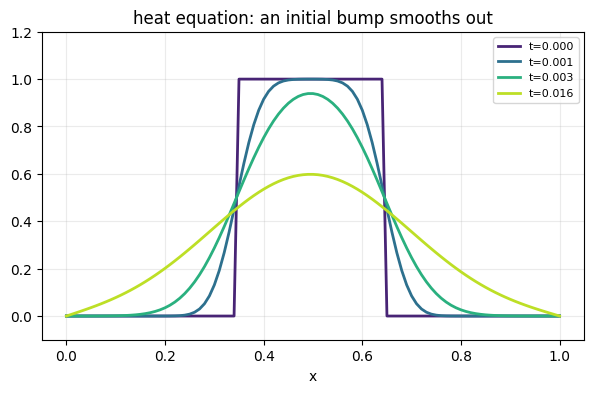

In [3]:
import numpy as np

# Heat equation smooths an initial bump over time (Dirichlet ends).
g = grids.Grid1D(0.0, 1.0, 101)
x, dx = g.x, g.dx
alpha = 1.0
dt = 0.4 * dx**2 / alpha
U = solvers.solve_heat_explicit(datasets.bump(x, 0.5, 0.15), alpha, dx, dt, steps=400)
ax = plotting.plot_field_snapshots(x, U, [0, 20, 80, 400], dt=dt,
                                   title="heat equation: an initial bump smooths out")
ax.set_ylim(-0.1, 1.2)
plt.show()

PDE には「時刻 $t$ ごとの場のスナップショット」という見方のほかに、
**横軸=空間・縦軸=時間** の **時空間ヒートマップ** という見方があります。拡散の広がりが見えます。

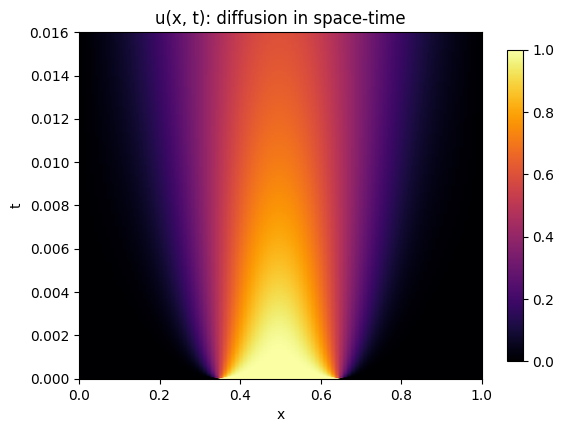

In [4]:
import numpy as np

# Same evolution as a space-time heatmap: the bump diffuses outward.
t = np.arange(U.shape[0]) * dt
plotting.space_time_heatmap(U, x, t, title="u(x, t): diffusion in space-time")
plt.show()

## 5. 問題の種類 — 時間発展問題と境界値問題 (Applied)

PDE は大きく 2 種類に分かれます。

- **時間発展問題**(放物型・双曲型): 初期条件から時間を前へ進める。**熱・移流・波動**(02 章)。
  → 必要なのは **初期条件** + **境界条件**。
- **境界値問題**(楕円型): 時間がなく、領域の縁の値から内部の定常状態を決める。**Laplace・Poisson**(03 章)。
  → 必要なのは **境界条件** のみ。

### 初期条件と境界条件

- **初期条件**: $t=0$ での場の形 $u(x, 0)$。
- **境界条件**: 領域の縁での約束。値を指定する **Dirichlet**、傾き(流量)を指定する **Neumann** など。

これらを取り違えると、解は一意に決まりません。

## 6. この教材の読み方

各章は **現象 → 直感 → 可視化 → 数式 → Python 実験 → 応用 → 発展** の流れ、
そして **Basic / Applied / Advanced** の 3 層構成です。

### 章構成 (PDE Book)

| Notebook | 内容 |
|---|---|
| `00_calculus_foundations` | 前提編: 微分=変化率 / 積分=蓄積 / 偏微分・勾配・Hessian |
| `01_overview` | PDE の全体像(この章) |
| `02_transport_heat_wave` | 移流・熱・波動 — 拡散と伝播 |
| `03_laplace_poisson_boundary_value` | Laplace・Poisson・境界条件・調和関数 |
| `04_fourier_series_and_transform` | Fourier 級数/変換 — 関数を波に分解 |
| `05_separation_of_variables` | 変数分離・固有関数・解析解 |
| `06_numerical_pde_fdm` | 有限差分法・安定性・CFL・数値拡散 |
| `07_applications_physics_finance_ml` | 物理・金融(Black-Scholes)・画像・拡散モデル |

### Python 環境の準備

```bash
cd ~/projects && make install                 # workspace 内(推奨)
# or standalone:
cd analytics/differential_equation/pde-book
python -m venv .venv && source .venv/bin/activate
pip install -r requirements.txt && pip install -e .
```

各 Notebook の最初のセルは、`pde_book` が未インストールでも `src/` を探して読み込みます。

## 7. Advanced Notes

- **PDE の分類**: 2 階線形 PDE $A u_{xx} + B u_{xy} + C u_{yy} + \dots$ は判別式 $B^2 - 4AC$ の符号で
  **楕円型**(<0; Laplace)・**放物型**(=0; 熱)・**双曲型**(>0; 波動)に分かれ、解の性質が大きく異なる。
- **適切性 (well-posedness)**: 解が「存在し・一意で・データに連続依存する」こと。境界/初期条件の付け方で決まる。
- **特性曲線**: 双曲型では情報が有限速度で特性に沿って伝わる(波動の伝播速度 $c$)。放物型では無限速度で瞬時に拡散する。